In [31]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Dosyalar
F1 = "mental_health_and_technology_usage_2024.csv"
F2 = "Tech_Use_Stress_Wellness.csv"
F3 = "mental_health_social_media_dataset.csv"

sns.set()


In [11]:
# ---------------------------------------------------------
# Amaç:
# Farklı veri setlerini ortak sütun yapısına getirmek,
# eksik sütunları güvenli şekilde eklemek ve
# veri yapısını okunabilir biçimde raporlamak.
# ---------------------------------------------------------

def ensure_cols(df, cols):
    # Veri setinin kopyasını al (orijinali korumak için)
    out = df.copy()
    
    # Beklenen sütunlar yoksa NaN değerlerle ekle
    for c in cols:
        if c not in out.columns:
            out[c] = np.nan
    
    # Sütun sırasını sabitleyerek geri döndür
    return out[cols]


def add_missingness_flags(df, cols):
    # Veri setinin kopyasını al
    df = df.copy()
    
    # Belirlenen sütunlar için eksik değer bayrağı oluştur
    # (Eksik mi? → 1, dolu mu? → 0)
    for c in cols:
        if c in df.columns:
            df[c + "_is_missing"] = df[c].isna().astype(int)
    
    return df


def pretty_print_columns(df, title="DATAFRAME"):
    # DataFrame genel bilgilerini yazdır
    print(f"\n================= 📌 {title} =================")
    print("Shape:", df.shape)
    print("Toplam sütun:", df.shape[1])

    # Sütunları veri tiplerine göre ayır
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
    bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()
    flag_cols = [c for c in df.columns if c.endswith("_is_missing")]
    target_cols = [c for c in df.columns if c in ["target"]]

    # Sütun gruplarını düzenli şekilde yazdıran yardımcı fonksiyon
    def print_block(name, cols):
        print(f"\n🔹 {name} ({len(cols)})")
        if not cols:
            print("   • (yok)")
        else:
            for c in cols:
                print(f"   • {c}")

    # Tüm sütun gruplarını ekrana bas
    print_block("NUMERİK SÜTUNLAR", numeric_cols)
    print_block("KATEGORİK SÜTUNLAR", categorical_cols)
    print_block("BOOLEAN SÜTUNLAR", bool_cols)
    print_block("MISSING FLAG SÜTUNLARI", flag_cols)
    print_block("TARGET SÜTUNLARI", target_cols)

    # Tüm kolonları tek satırda göster
    print("\n📋 Kolonlar (tek satır):")
    print(list(df.columns))
    print("================================================\n")

In [ ]:
def analyze_feature_importance(df, target_col="mental_health_score", threshold=0.10):
    # ---------------------------------------------------------
    # Amaç:
    # 1) Sayısal sütunlarda korelasyon matrisi üretmek
    # 2) Target ile korelasyonlara göre sütunları yorumlayıp
    #    (leakage / birleştirme / seçme / zayıf ama tutma) karar vermek
    # 3) Korelasyonları heatmap ile görselleştirmek
    # ---------------------------------------------------------

    print(f"\n📊 ADIM 1: KORELASYON ANALİZİ VE SÜTUN ELEME MANTIĞI")
    print("-" * 60)

    # Sadece sayısal sütunları seç (korelasyon hesaplamak için)
    numeric_df = df.select_dtypes(include=[np.number])

    # Sayısal sütunların korelasyon matrisini hesapla
    corr_matrix = numeric_df.corr()

    # Target sütunu yoksa güvenli şekilde çık
    if target_col not in corr_matrix.columns:
        print(f"⚠️ '{target_col}' bulunamadı. Korelasyon analizi atlandı.")
        return

    # Target ile diğer değişkenlerin korelasyonlarını al (target hariç)
    target_corr = corr_matrix[target_col].drop(target_col)

    # Tablo başlığını yazdır
    print(f"{'DEĞİŞKEN':<30} | {'KORELASYON':<10} | {'KARAR'}")
    print("-" * 60)

    # Her değişken için korelasyon değerine göre karar üret
    for col, val in target_corr.items():
        # Leakage riski olan sütunlar (hedefe çok yakın/benzer sinyal taşıyabilir)
        if col in ["stress_level", "weekly_depression_score", "weekly_anxiety_score", "mood_rating"]:
            decision = "⛔ ÇIKARILDI (Leakage riski)"

        # Aynı kavramı ölçen ekran süresi bileşenleri (tek değişkende birleştirme mantığı)
        elif col in ["phone_usage_hours", "laptop_usage_hours", "tv_usage_hours", "tablet_usage_hours"]:
            decision = "🔄 BİRLEŞTİRİLDİ (screen_time içine)"

        # Korelasyon eşiğini geçenler (daha güçlü ilişki)
        elif abs(val) >= threshold:
            decision = "✅ SEÇİLDİ (Güçlü ilişki)"

        # Eşiğin altında kalanlar (zayıf ama tamamen atılmayabilir)
        else:
            decision = "⚠️ ZAYIF AMA TUTULUYOR"

        # Satırı yazdır
        print(f"{col:<30} | {val:>8.4f}   | {decision}")

    print("-" * 60)

    # Kullanıcıya karar mantığını açıklayan kısa not
    print("NOT: 'stress_level' vb. değişkenler hedefe çok yakınsa modelin kopya çekmesine neden olabilir.\n")

    # Korelasyon matrisini heatmap ile görselleştir
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, cmap='coolwarm', fmt=".2f")
    plt.title("Değişken İlişkileri (Heatmap)")
    plt.tight_layout()
    plt.show()


🔍 ADIM 1: F2 Üzerinde Korelasyon Analizi Yapılıyor...
 🗑️ 'user_id' elendi (Zayıf ilişki: -0.00)
 ✅ 'age' seçildi (Korelasyon: 0.37)
 ✅ 'screen_time' seçildi (Korelasyon: -0.62)
 ✅ 'phone_usage_hours' seçildi (Korelasyon: -0.27)
 ✅ 'laptop_usage_hours' seçildi (Korelasyon: -0.29)
 ✅ 'tablet_usage_hours' seçildi (Korelasyon: -0.16)
 ✅ 'tv_usage_hours' seçildi (Korelasyon: -0.26)
 ✅ 'social_media' seçildi (Korelasyon: -0.86)
 ✅ 'work_related_hours' seçildi (Korelasyon: -0.75)
 ✅ 'entertainment_hours' seçildi (Korelasyon: 0.65)
 ✅ 'gaming' seçildi (Korelasyon: 0.67)
 ✅ 'sleep' seçildi (Korelasyon: 0.25)
 ✅ 'sleep_quality' seçildi (Korelasyon: 0.43)
 ✅ 'physical_activity_hours_per_week' seçildi (Korelasyon: 0.79)
 🗑️ 'caffeine_intake_mg_per_day' elendi (Zayıf ilişki: -0.07)
 ✅ 'mindfulness_minutes_per_day' seçildi (Korelasyon: 0.65)
 ✅ 'activity' seçildi (Korelasyon: 0.79)


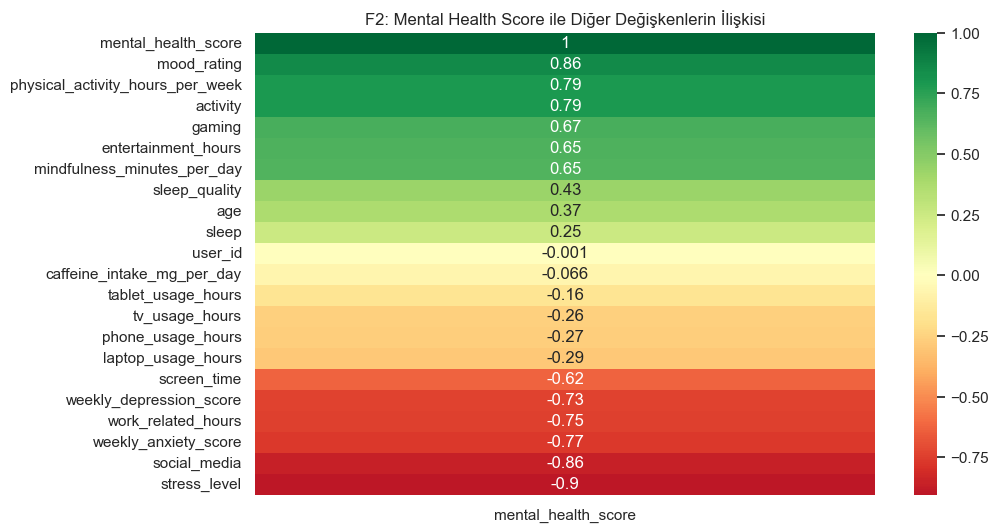


🎯 FİNAL ŞABLON OLUŞTU: ['source', 'age', 'sleep', 'tv_usage_hours', 'gender', 'laptop_usage_hours', 'mental_health_score', 'mindfulness_minutes_per_day', 'phone_usage_hours', 'tablet_usage_hours', 'social_media', 'gaming', 'physical_activity_hours_per_week', 'activity', 'entertainment_hours', 'label_available', 'screen_time', 'platform', 'work_related_hours', 'sleep_quality']

🛠️ Tüm veri setleri 'Altın Şablona' göre birleştiriliyor...

✅ İŞLEM TAMAM!
Şu an veri setinde 20 sütun ve 20000 satır var.
      source  age  sleep  tv_usage_hours  gender  laptop_usage_hours  \
14423     F2   29   7.80             2.7    Male                 0.0   
3611      F1   22   7.01             NaN    Male                 NaN   
7596      F1   23   6.69             NaN   Other                 NaN   
17220     F3   60    NaN             NaN  Female                 NaN   
3862      F1   42   8.82             NaN   Other                 NaN   

       mental_health_score  mindfulness_minutes_per_day  phone

/opt/anaconda3/lib/python3.11/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


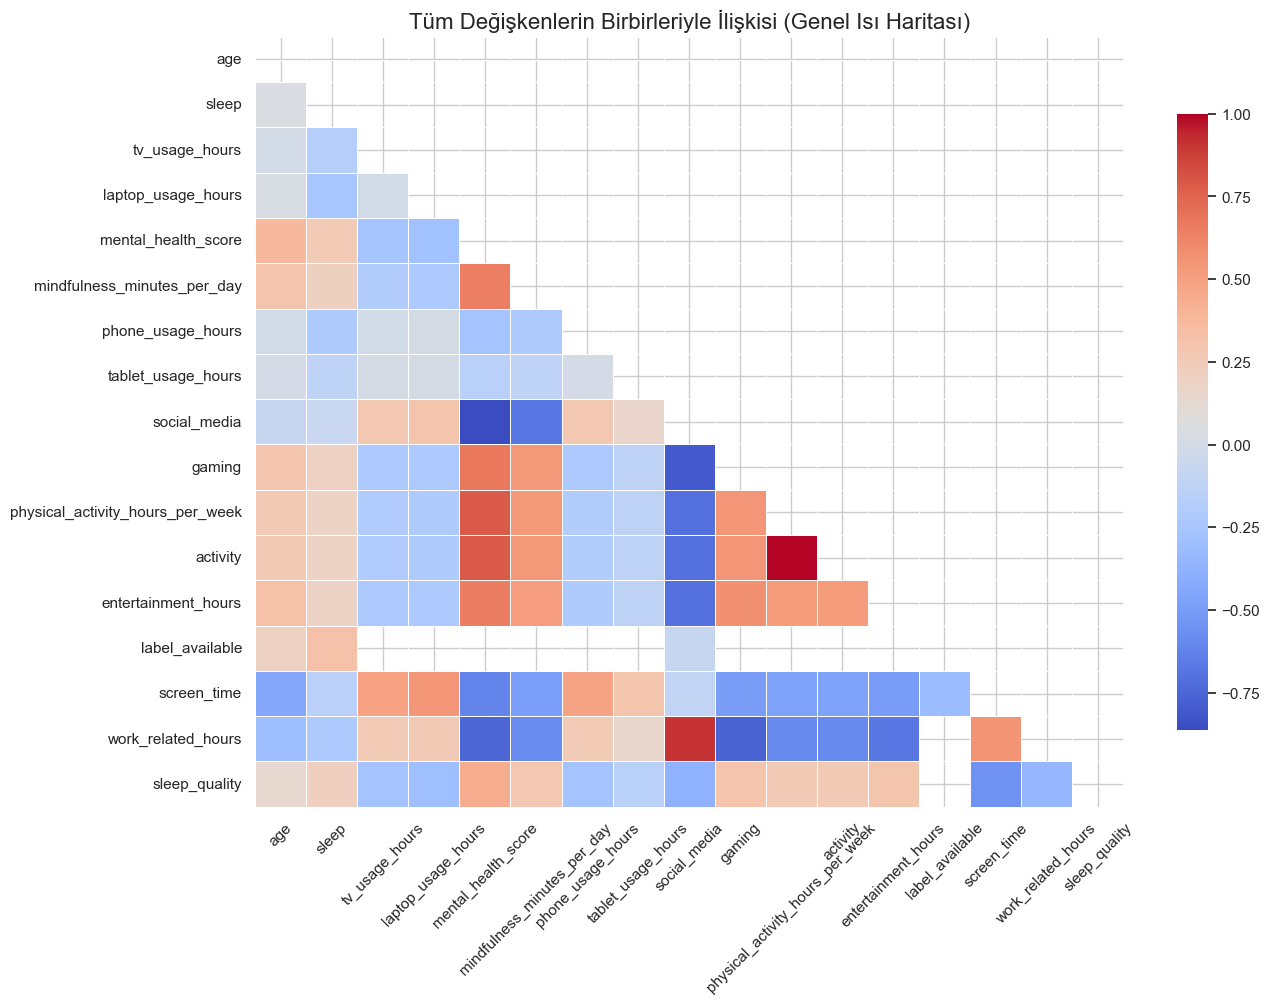

In [ ]:
# =========================================================
# GEREKLİ KÜTÜPHANELER
# =========================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# 1) DOSYA YOLLARI (3 farklı veri seti)
# =========================================================
F1_PATH = "mental_health_and_technology_usage_2024.csv"
F2_PATH = "Tech_Use_Stress_Wellness.csv"
F3_PATH = "mental_health_social_media_dataset.csv"

# =========================================================
# 2) SABİT AYARLAR
# =========================================================
TARGET_COL = "mental_health_score"

# Korelasyonu düşük çıksa bile modelde mutlaka olması gereken sütunlar
MANDATORY_COLS = ["age", "gender", "platform", "source", "label_available", TARGET_COL]

# Modelin kopya çekmesini engelleyecek (başka testlerden gelen) skorlar (leakage)
LEAKAGE_COLS = ["stress_level", "weekly_depression_score", "weekly_anxiety_score", "mood_rating"]

def get_dynamic_features_from_f2(df_f2, threshold=0.10):
    """
    AMAÇ:
    - Sadece F2 veri setine bakarak, mental_health_score (TARGET_COL) ile
      anlamlı ilişkisi olan sayısal sütunları korelasyonla seçmek.
    - Leakage sütunlarını tamamen dışarıda bırakmak.
    - Seçim sonucunu küçük bir heatmap ile görselleştirmek.
    """
    print(f"\n🔍 ADIM 1: F2 Üzerinde Korelasyon Analizi Yapılıyor...")
    
    # Sadece sayısal sütunları seç (korelasyon için)
    numeric_f2 = df_f2.select_dtypes(include=[np.number])
    
    # Korelasyon matrisini hesapla
    corr_matrix = numeric_f2.corr()
    
    # Target ile diğer sütunların korelasyonunu al (target hariç)
    target_corr = corr_matrix[TARGET_COL].drop(TARGET_COL)
    
    selected_cols = []
    
    # Korelasyon eşiğine göre seçim/eleme kararı
    for col, val in target_corr.items():
        # Leakage sütunlarını atla (modele sızıntı yaptırmamak için)
        if col in LEAKAGE_COLS:
            continue
        # Eşik üstündeyse seç
        if abs(val) >= threshold:
            selected_cols.append(col)
            print(f" ✅ '{col}' seçildi (Korelasyon: {val:.2f})")
        # Eşik altındaysa ele
        else:
            print(f" 🗑️ '{col}' elendi (Zayıf ilişki: {val:.2f})")
            
    # Target ile korelasyonları (tek sütun) heatmap olarak göster
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        corr_matrix[[TARGET_COL]].sort_values(by=TARGET_COL, ascending=False),
        annot=True, cmap='RdYlGn', center=0
    )
    plt.title("F2: Mental Health Score ile Diğer Değişkenlerin İlişkisi")
    plt.show()
    
    # Seçilen önemli sayısal feature’ları döndür
    return selected_cols

def build_pipeline():
    # =========================================================
    # 3) VERİLERİ YÜKLE
    # =========================================================
    df2 = pd.read_csv(F2_PATH)
    df1 = pd.read_csv(F1_PATH)
    df3 = pd.read_csv(F3_PATH)

    # =========================================================
    # 4) F2 ÖN İŞLEME VE ANALİZ
    # =========================================================

    # Birimleri eşitle: Haftalık aktivite saatini günlük ortalamaya çevir
    if "physical_activity_hours_per_week" in df2.columns:
        df2["activity"] = df2["physical_activity_hours_per_week"] / 7
        
    # F2’deki sütunları ortak isimlere standardize et
    df2 = df2.rename(columns={
        "daily_screen_time_hours": "screen_time",
        "social_media_hours": "social_media",
        "gaming_hours": "gaming",
        "sleep_duration_hours": "sleep"
    })

    # F2 üzerinden otomatik (dinamik) önemli sütunları öğren
    important_features = get_dynamic_features_from_f2(df2)
    
    # FINAL_COLS: tüm datasetlerin uyması gereken “altın şablon”
    FINAL_COLS = list(set(MANDATORY_COLS + important_features))
    print(f"\n🎯 FİNAL ŞABLON OLUŞTU: {FINAL_COLS}")

    # =========================================================
    # 5) DİĞER VERİ SETLERİNİ ŞABLONA UYDURMA FONKSİYONU
    # =========================================================
    def standardize(df, source_name, is_labeled=False):
        # Orijinal veriyi bozmamak için kopya al
        d = df.copy()

        # F1/F3 gibi veri setlerinden gelebilecek farklı sütun adlarını ortaklaştır
        rename_map = {
            "Age": "age", "Gender": "gender", "Sleep_Hours": "sleep",
            "Screen_Time_Hours": "screen_time", "Social_Media_Usage_Hours": "social_media",
            "daily_screen_time_min": "screen_time", "social_media_time_min": "social_media"
        }
        d = d.rename(columns=rename_map)
        
        # Eğer dakika bazlı bir sütun varsa (F3 gibi), saat’e dönüştür
        if "social_media_time_min" in df.columns:
            d["social_media"] = d["social_media"] / 60
            
        # Kaynak bilgisi (hangi datasetten geldi?)
        d["source"] = source_name

        # Etiket var mı? (Sadece etiketli olanlar model eğitiminde kullanılacak)
        d["label_available"] = 1 if is_labeled else 0
        
        # Final şablondaki eksik sütunları NaN ile ekle, fazla sütunları at
        for col in FINAL_COLS:
            if col not in d.columns:
                d[col] = np.nan

        # Şablona göre sıralanmış halde döndür
        return d[FINAL_COLS]

    # =========================================================
    # 6) BİRLEŞTİRME (Tüm datasetleri ortak şablonda birleştir)
    # =========================================================
    print("\n🛠️ Tüm veri setleri 'Altın Şablona' göre birleştiriliyor...")
    f1_final = standardize(df1, "F1", is_labeled=False)
    f2_final = standardize(df2, "F2", is_labeled=True)
    f3_final = standardize(df3, "F3", is_labeled=False)

    # Hepsini tek bir DataFrame’de birleştir
    full_data = pd.concat([f1_final, f2_final, f3_final], ignore_index=True)

    # =========================================================
    # 7) BASİT TEMİZLİK: Cinsiyet alanını tutarlı hale getir
    # =========================================================
    full_data["gender"] = full_data["gender"].astype(str).str.title().replace({
        "Man": "Male", "Woman": "Female", "Erkek": "Male", "Kadın": "Female"
    })

    # Birleştirilmiş final veriyi döndür
    return full_data

# =========================================================
# 8) ÇALIŞTIR: Final dataset’i üret
# =========================================================
final_dataset = build_pipeline()

print("\n✅ İŞLEM TAMAM!")
print(f"Şu an veri setinde {final_dataset.shape[1]} sütun ve {len(final_dataset)} satır var.")
print(final_dataset.sample(5)) # Rastgele 5 satır göster



import seaborn as sns
import matplotlib.pyplot as plt

def plot_full_heatmap(df):
    """
    AMAÇ:
    - Tüm sayısal değişkenlerin birbirleriyle olan korelasyonunu
      genel bir korelasyon ısı haritası (heatmap) ile göstermek.
    """
    # Sadece sayısal sütunları al
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Korelasyon matrisini hesapla
    corr = numeric_df.corr()
    
    # Figure boyutu
    plt.figure(figsize=(14, 10))
    
    # Üst üçgeni maskele (simetrik tekrarları göstermemek için)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    # Heatmap çizimi
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        linewidths=0.5,
        cbar_kws={"shrink": .8}
    )
    
    # Grafik başlığı ve eksen düzeni
    plt.title("Tüm Değişkenlerin Birbirleriyle İlişkisi (Genel Isı Haritası)", fontsize=16)
    plt.xticks(rotation=45)
    plt.show()

# =========================================================
# 9) GRAFİĞİ ÇAĞIR: final_dataset oluştuktan sonra çalışır
# =========================================================
plot_full_heatmap(final_dataset)

In [ ]:
def build_merged_final(f1, f2, f3, run_analysis=True):
    # ---------------------------------------------------------
    # Amaç:
    # 1) 3 farklı CSV veri setini (F1, F2, F3) ortak bir şablonda birleştirmek
    # 2) Sütun isimlerini standardize etmek ve zaman birimlerini eşitlemek
    # 3) Etiketli/etiketsiz kayıtları label_available ile ayırmak
    # 4) Gerekirse (run_analysis=True) F2 üzerinde korelasyon analizini çalıştırmak
    # ---------------------------------------------------------

    print("Veri setleri yükleniyor ve ön işleme tabi tutuluyor...")

    # -----------------------------
    # (A) F2 geçici analiz + rename
    # -----------------------------
    # F2 dosyasını oku (ham)
    df2_raw = pd.read_csv(f2)
    df2_temp = df2_raw.copy()

    # Haftalık aktivite -> günlük ortalama saat (weekly -> daily hours)
    if "physical_activity_hours_per_week" in df2_temp.columns:
        df2_temp["activity"] = pd.to_numeric(df2_temp["physical_activity_hours_per_week"], errors="coerce") / 7

    # Kullanıcıya yapılan dönüşümleri yazdır (sunum/rapor için şeffaflık)
    print("\n🔄 SÜTUN DÖNÜŞÜMLERİ (F2):")
    print("   - 'daily_screen_time_hours' -> 'screen_time'")
    print("   - 'social_media_hours'      -> 'social_media'")
    print("   - 'gaming_hours'            -> 'gaming'")
    print("   - 'work_related_hours'      -> 'work_hours'")
    print("   - 'sleep_duration_hours'    -> 'sleep'")
    print("   - 'caffeine_intake_mg_per_day' -> 'caffeine'")

    # F2 sütunlarını ortak isimlere çevir (analiz için temp üzerinde)
    df2_temp = df2_temp.rename(columns={
        "daily_screen_time_hours": "screen_time",
        "social_media_hours": "social_media",
        "gaming_hours": "gaming",
        "work_related_hours": "work_hours",
        "sleep_duration_hours": "sleep",
        "caffeine_intake_mg_per_day": "caffeine"
    })

    # İstenirse F2 üzerinden korelasyon analizi çalıştır
    if run_analysis:
        analyze_feature_importance(df2_temp, target_col="mental_health_score", threshold=0.10)

    # -----------------------------
    # (B) Sabit şablon (FIXED_TARGET_COLS)
    # -----------------------------
    # Tüm datasetlerin aynı sütun yapısına uyması için “altın şablon”
    FIXED_TARGET_COLS = [
        "age", "gender", "screen_time", "social_media", "gaming", "work_hours",
        "sleep", "activity", "caffeine", "support", "platform", "source",
        "label_available", "negative_interactions_count", "positive_interactions_count",
        "mental_health_score"
    ]

    print("\n📝 ADIM 2: FINAL SÜTUN ŞABLONU")
    print(f"-> ({len(FIXED_TARGET_COLS)} adet) {FIXED_TARGET_COLS}")

    # -----------------------------
    # (C) DF1 standardizasyon (etiketsiz)
    # -----------------------------
    # F1 dosyasını oku
    df1 = pd.read_csv(f1)

    # F1 sütunlarını ortak isimlere çevir
    df1_sel = df1.rename(columns={
        "Age": "age",
        "Gender": "gender",
        "Screen_Time_Hours": "screen_time",
        "Social_Media_Usage_Hours": "social_media",
        "Gaming_Hours": "gaming",
        "Sleep_Hours": "sleep",
        "Physical_Activity_Hours": "activity",
        "Support_Systems_Access": "support"
    })

    # Kaynak ve etiket bilgisi ekle
    df1_sel["source"] = "df1"
    df1_sel["label_available"] = 0

    # -----------------------------
    # (D) DF2 standardizasyon (etiketli)
    # -----------------------------
    # F2 dosyasını tekrar oku (orijinal haliyle)
    df2 = pd.read_csv(f2)

    # Haftalık aktivite -> günlük
    if "physical_activity_hours_per_week" in df2.columns:
        df2["activity"] = pd.to_numeric(df2["physical_activity_hours_per_week"], errors="coerce") / 7

    # F2 sütunlarını ortak isimlere çevir
    df2_sel = df2.rename(columns={
        "age": "age",
        "gender": "gender",
        "daily_screen_time_hours": "screen_time",
        "social_media_hours": "social_media",
        "gaming_hours": "gaming",
        "work_related_hours": "work_hours",
        "sleep_duration_hours": "sleep",
        "caffeine_intake_mg_per_day": "caffeine",
        "mental_health_score": "mental_health_score"
    })

    # Kaynak ve etiket bilgisi ekle (F2 etiketli kabul ediliyor)
    df2_sel["source"] = "df2"
    df2_sel["label_available"] = 1

    # -----------------------------
    # (E) DF3 standardizasyon (etiketsiz)
    # -----------------------------
    # F3 dosyasını oku
    df3 = pd.read_csv(f3)

    # Dakika -> saat dönüşümleri (F3 dakika bazlı olabilir)
    if "daily_screen_time_min" in df3.columns:
        df3["screen_time"] = pd.to_numeric(df3["daily_screen_time_min"], errors="coerce") / 60
    if "social_media_time_min" in df3.columns:
        df3["social_media"] = pd.to_numeric(df3["social_media_time_min"], errors="coerce") / 60
    if "sleep_hours" in df3.columns:
        df3["sleep"] = pd.to_numeric(df3["sleep_hours"], errors="coerce")
    if "physical_activity_min" in df3.columns:
        df3["activity"] = pd.to_numeric(df3["physical_activity_min"], errors="coerce") / 60

    # DF3’te gerekli sütunlar zaten aynı isimdeyse sadece seçime hazırlık yapılır
    df3_sel = df3.rename(columns={
        "platform": "platform",
        "negative_interactions_count": "negative_interactions_count",
        "positive_interactions_count": "positive_interactions_count"
    })

    # Kaynak ve etiket bilgisi ekle
    df3_sel["source"] = "df3"
    df3_sel["label_available"] = 0

    # -----------------------------
    # (F) Şablona uydur + concat
    # -----------------------------
    # ensure_cols: eksik sütunları NaN ile ekler ve sütun sırasını sabitler
    df1_final = ensure_cols(df1_sel, FIXED_TARGET_COLS)
    df2_final = ensure_cols(df2_sel, FIXED_TARGET_COLS)
    df3_final = ensure_cols(df3_sel, FIXED_TARGET_COLS)

    # Üç veri setini birleştir
    merged = pd.concat([df1_final, df2_final, df3_final], ignore_index=True)

    # -----------------------------
    # (G) Temizlik (kategorik alanları standardize et)
    # -----------------------------
    # Cinsiyet değerlerini tutarlı hale getir
    merged["gender"] = merged["gender"].astype(str).str.strip().str.title()
    merged["gender"] = (
        merged["gender"]
        .replace({"Man":"Male","Woman":"Female","Erkek":"Male","Kadın":"Female","Nan":"Unknown"})
        .replace("Unknown", np.nan)
        .fillna("Unknown")
    )

    # Boş support/platform değerlerini Unknown ile doldur
    merged["support"] = merged["support"].fillna("Unknown")
    merged["platform"] = merged["platform"].fillna("Unknown")

    # Birleştirilmiş final veriyi döndür
    return merged

Veri setleri yükleniyor ve ön işleme tabi tutuluyor...

🔄 SÜTUN DÖNÜŞÜMLERİ (F2):
   - 'daily_screen_time_hours' -> 'screen_time'
   - 'social_media_hours'      -> 'social_media'
   - 'gaming_hours'            -> 'gaming'
   - 'work_related_hours'      -> 'work_hours'
   - 'sleep_duration_hours'    -> 'sleep'
   - 'caffeine_intake_mg_per_day' -> 'caffeine'

📊 ADIM 1: KORELASYON ANALİZİ VE SÜTUN ELEME MANTIĞI
------------------------------------------------------------
DEĞİŞKEN                       | KORELASYON | KARAR
------------------------------------------------------------
user_id                        |  -0.0010   | ⚠️ ZAYIF AMA TUTULUYOR
age                            |   0.3732   | ✅ SEÇİLDİ (Güçlü ilişki)
screen_time                    |  -0.6218   | ✅ SEÇİLDİ (Güçlü ilişki)
phone_usage_hours              |  -0.2662   | 🔄 BİRLEŞTİRİLDİ (screen_time içine)
laptop_usage_hours             |  -0.2869   | 🔄 BİRLEŞTİRİLDİ (screen_time içine)
tablet_usage_hours             |  -0.16

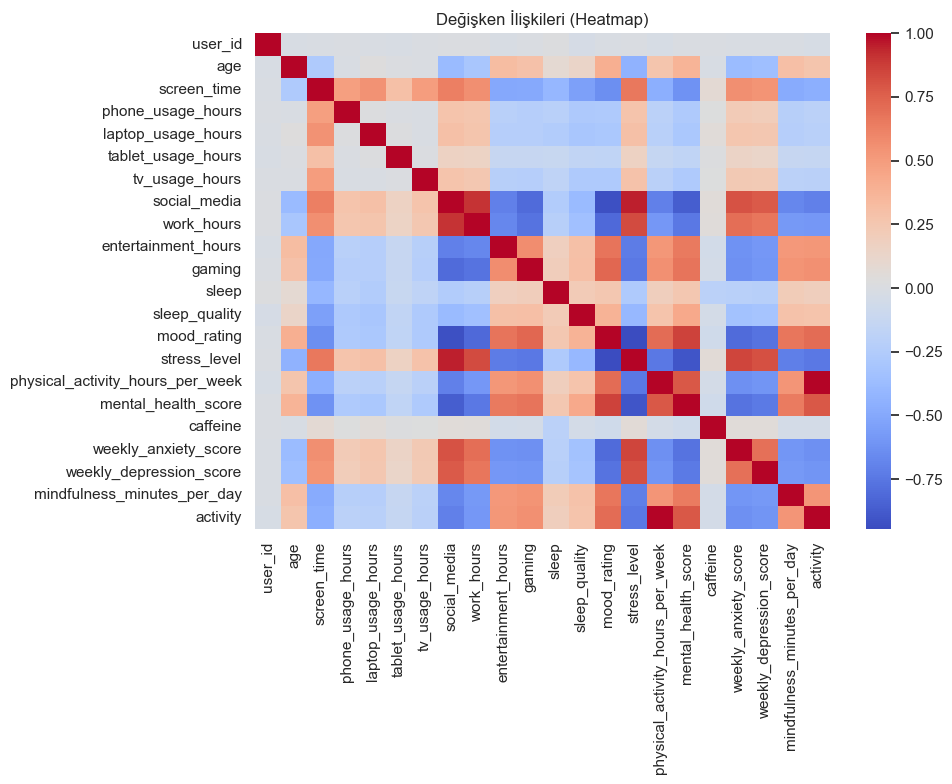


📝 ADIM 2: FINAL SÜTUN ŞABLONU
-> (16 adet) ['age', 'gender', 'screen_time', 'social_media', 'gaming', 'work_hours', 'sleep', 'activity', 'caffeine', 'support', 'platform', 'source', 'label_available', 'negative_interactions_count', 'positive_interactions_count', 'mental_health_score']

✅ İŞLEM TAMAMLANDI!
Sonuç shape: (20000, 16)


,age,gender,screen_time,social_media,gaming,work_hours,sleep,activity,caffeine,support,platform,source,label_available,negative_interactions_count,positive_interactions_count,mental_health_score
0,23,Female,12.36,6.00,0.68,NaN,8.01,6.71,NaN,No,Unknown,df1,0,NaN,NaN,NaN
1,21,Male,7.61,2.57,3.74,NaN,7.28,5.88,NaN,Yes,Unknown,df1,0,NaN,NaN,NaN
2,51,Male,3.16,6.14,1.26,NaN,8.04,9.81,NaN,No,Unknown,df1,0,NaN,NaN,NaN
3,25,Female,13.08,4.48,2.59,NaN,5.62,5.28,NaN,Yes,Unknown,df1,0,NaN,NaN,NaN
4,53,Male,12.63,0.56,0.29,NaN,5.55,4.00,NaN,No,Unknown,df1,0,NaN,NaN,NaN


In [35]:
merged = build_merged_final(F1, F2, F3, run_analysis=True)

print("\n✅ İŞLEM TAMAMLANDI!")
print("Sonuç shape:", merged.shape)
display(merged.head())


In [37]:
FLAG_COLS = ["work_hours","caffeine","negative_interactions_count","positive_interactions_count","mental_health_score"]

merged2 = add_missingness_flags(merged, FLAG_COLS)

pretty_print_columns(merged2, title="merged2 (flag eklenmiş)")



================= 📌 merged2 (flag eklenmiş) =================
Shape: (20000, 21)
Toplam sütun: 21

🔹 NUMERİK SÜTUNLAR (17)
   • age
   • screen_time
   • social_media
   • gaming
   • work_hours
   • sleep
   • activity
   • caffeine
   • label_available
   • negative_interactions_count
   • positive_interactions_count
   • mental_health_score
   • work_hours_is_missing
   • caffeine_is_missing
   • negative_interactions_count_is_missing
   • positive_interactions_count_is_missing
   • mental_health_score_is_missing

🔹 KATEGORİK SÜTUNLAR (4)
   • gender
   • support
   • platform
   • source

🔹 BOOLEAN SÜTUNLAR (0)
   • (yok)

🔹 MISSING FLAG SÜTUNLARI (5)
   • work_hours_is_missing
   • caffeine_is_missing
   • negative_interactions_count_is_missing
   • positive_interactions_count_is_missing
   • mental_health_score_is_missing

🔹 TARGET SÜTUNLARI (0)
   • (yok)

📋 Kolonlar (tek satır):
['age', 'gender', 'screen_time', 'social_media', 'gaming', 'work_hours', 'sleep', 'activity', 'caff

In [38]:
df_labeled = merged2[merged2["label_available"] == 1].copy()
print("df_labeled shape:", df_labeled.shape)


df_labeled shape: (5000, 21)


In [ ]:
# ---------------------------------------------------------
# Amaç:
# Mental sağlık skorunu kullanarak ikili bir hedef (target) oluşturmak.
# Süreç:
# 1) Skoru sayısal formata çevir
# 2) Eksik değerleri medyan ile doldur
# 3) Medyanı eşik (threshold) olarak al
# 4) Skora göre 0/1 target üret
# ---------------------------------------------------------

# Mental sağlık skorunu sayısal formata çevir (hatalı değerleri NaN yap)
score = pd.to_numeric(df_labeled["mental_health_score"], errors="coerce")

# Eksik skorları medyan değer ile doldur
score = score.fillna(score.median())

# Medyan değeri eşik olarak belirle
thr = score.median()

# Skoru medyanın altındaysa 1 (riskli), üstündeyse 0 (sağlıklı) olacak şekilde target oluştur
df_labeled["target"] = (score < thr).astype(int)

# Target sınıflarının oranlarını yazdır (sınıf dengesi kontrolü)
print(df_labeled["target"].value_counts(normalize=True))

target
0    0.5028
1    0.4972
Name: proportion, dtype: float64


In [ ]:
# ---------------------------------------------------------
# Amaç:
# Model eğitiminde kullanılacak feature (X) ve target (y)
# setlerini net ve sızıntısız şekilde ayırmak.
# ---------------------------------------------------------

# Model için kesinlikle kullanılmaması gereken sütunlar
DROP_FOR_MODEL = ["target", "mental_health_score"]  # en kritik ikisi

# Opsiyonel olarak düşünebileceğin ek sütunlar:
# - label_available: Etiket var/yok bilgisi modele katkı sağlamaz
# - source: Veri kaynağı bilgisi domain-bias oluşturabilir
# - mental_health_score_is_missing: Target’a dolaylı sinyal verebilir
# DROP_FOR_MODEL += ["label_available"]
# DROP_FOR_MODEL += ["source"]
# DROP_FOR_MODEL += ["mental_health_score_is_missing"]

# Feature seti (X): Drop listesinde olan sütunları çıkar
X = df_labeled.drop(columns=[c for c in DROP_FOR_MODEL if c in df_labeled.columns])

# Target (y): Daha önce oluşturulan ikili hedef değişken
y = df_labeled["target"].copy()

# Boyut kontrolü
print("X shape:", X.shape, "y shape:", y.shape)

# Feature setinin yapısını detaylı ve okunabilir şekilde yazdır
pretty_print_columns(X, title="X (Model Feature Set)")

X shape: (5000, 20) y shape: (5000,)

================= 📌 X (Model Feature Set) =================
Shape: (5000, 20)
Toplam sütun: 20

🔹 NUMERİK SÜTUNLAR (16)
   • age
   • screen_time
   • social_media
   • gaming
   • work_hours
   • sleep
   • activity
   • caffeine
   • label_available
   • negative_interactions_count
   • positive_interactions_count
   • work_hours_is_missing
   • caffeine_is_missing
   • negative_interactions_count_is_missing
   • positive_interactions_count_is_missing
   • mental_health_score_is_missing

🔹 KATEGORİK SÜTUNLAR (4)
   • gender
   • support
   • platform
   • source

🔹 BOOLEAN SÜTUNLAR (0)
   • (yok)

🔹 MISSING FLAG SÜTUNLARI (5)
   • work_hours_is_missing
   • caffeine_is_missing
   • negative_interactions_count_is_missing
   • positive_interactions_count_is_missing
   • mental_health_score_is_missing

🔹 TARGET SÜTUNLARI (0)
   • (yok)

📋 Kolonlar (tek satır):
['age', 'gender', 'screen_time', 'social_media', 'gaming', 'work_hours', 'sleep', 'activit

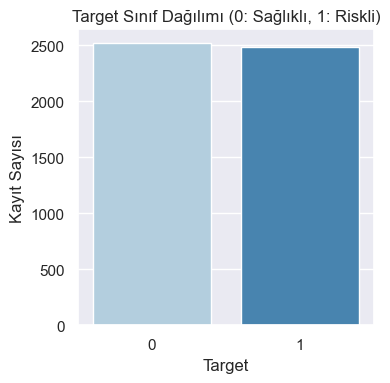

In [ ]:
# ---------------------------------------------------------
# Amaç:
# Oluşturulan target değişkeninin sınıf dağılımını görselleştirmek.
# Bu grafik ile:
# - Sınıflar dengeli mi?
# - Ciddi bir class imbalance var mı?
# sorularına hızlıca cevap verilir.
# ---------------------------------------------------------

# Grafik boyutunu ayarla
plt.figure(figsize=(4, 4))

# Target sınıf dağılımını çiz (0: Sağlıklı, 1: Riskli)
sns.countplot(
    x="target",
    data=df_labeled,
    palette="Blues"
)

# Grafik başlığı ve eksen isimleri
plt.title("Target Sınıf Dağılımı (0: Sağlıklı, 1: Riskli)")
plt.xlabel("Target")
plt.ylabel("Kayıt Sayısı")

# Grafik düzenini sıkılaştır
plt.tight_layout()

# Grafiği göster
plt.show()

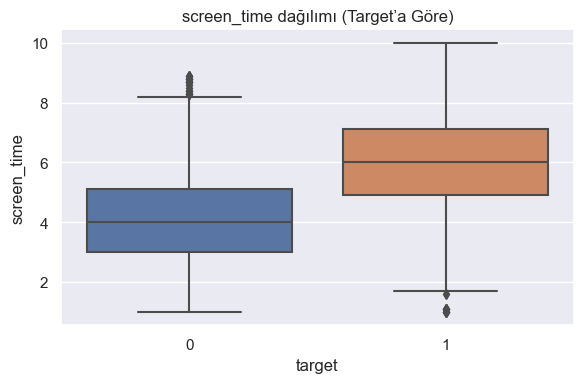

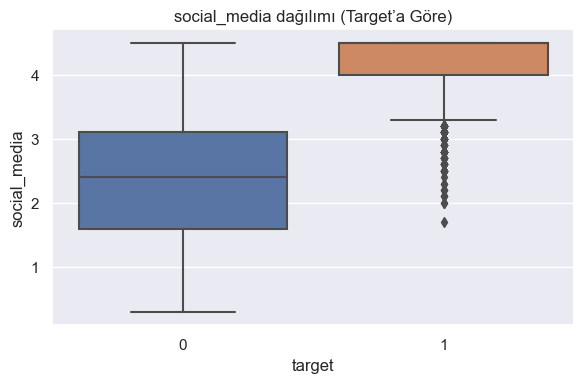

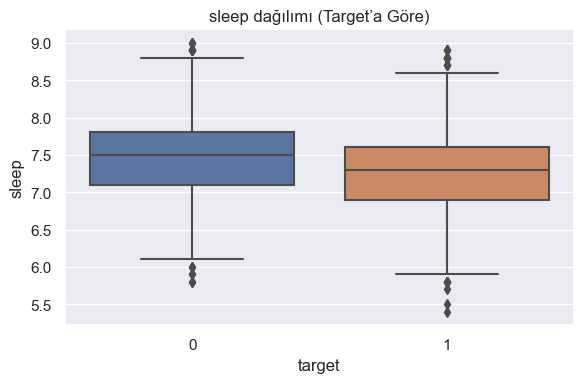

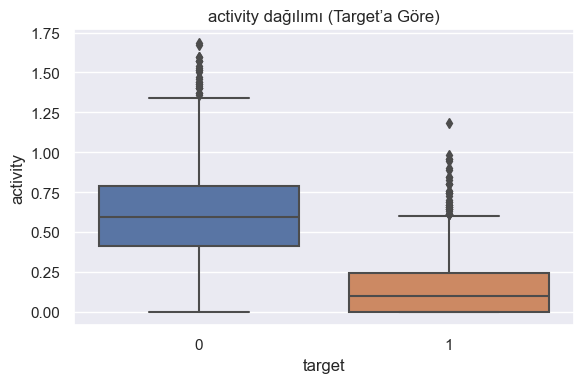

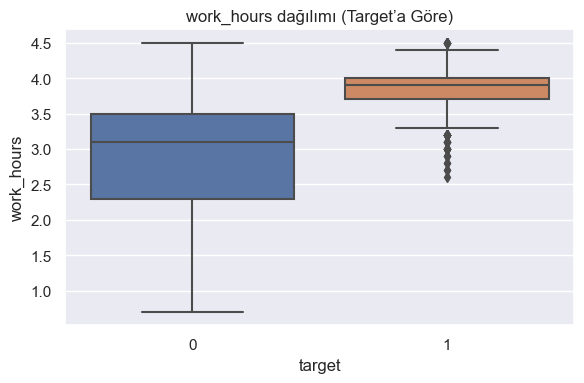

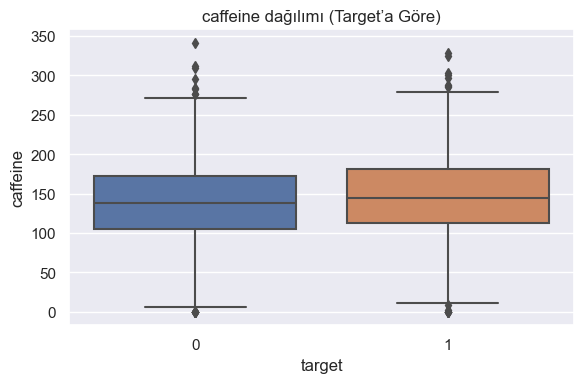

In [42]:
num_viz_cols = ["screen_time", "social_media", "sleep", "activity", "work_hours", "caffeine"]

for col in num_viz_cols:
    if col in df_labeled.columns:
        plt.figure(figsize=(6,4))
        sns.boxplot(x="target", y=col, data=df_labeled)
        plt.title(f"{col} dağılımı (Target’a Göre)")
        plt.tight_layout()
        plt.show()


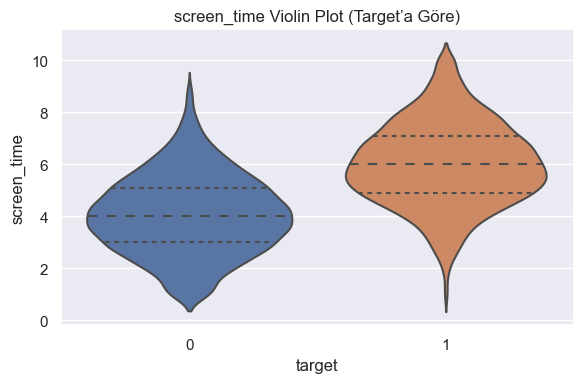

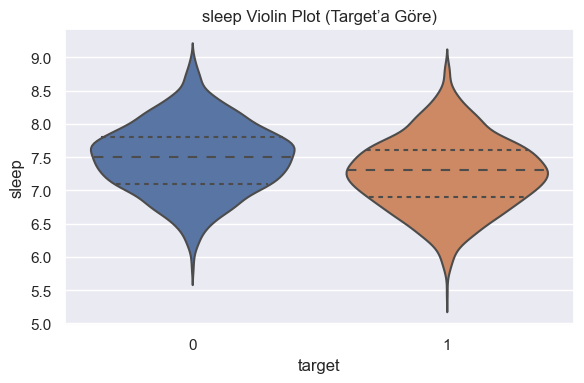

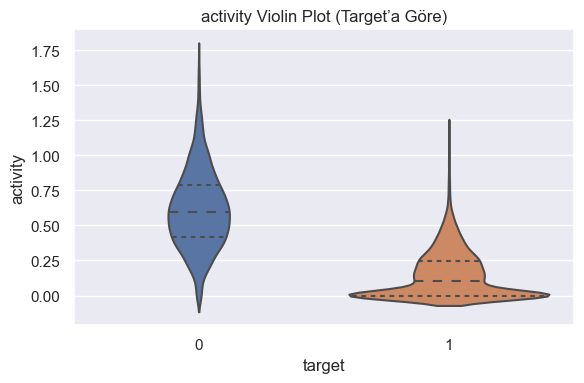

In [43]:
for col in ["screen_time", "sleep", "activity"]:
    if col in df_labeled.columns:
        plt.figure(figsize=(6,4))
        sns.violinplot(x="target", y=col, data=df_labeled, inner="quartile")
        plt.title(f"{col} Violin Plot (Target’a Göre)")
        plt.tight_layout()
        plt.show()


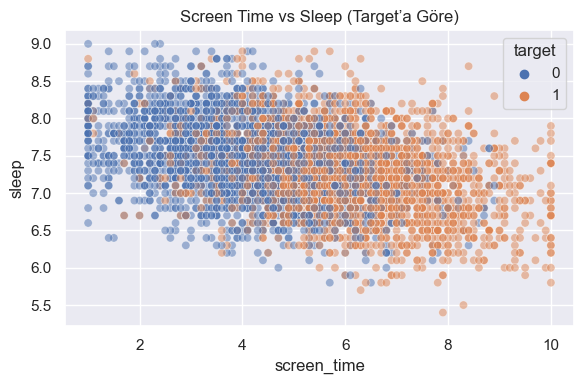

In [44]:
if "screen_time" in df_labeled.columns and "sleep" in df_labeled.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df_labeled, x="screen_time", y="sleep", hue="target", alpha=0.5)
    plt.title("Screen Time vs Sleep (Target’a Göre)")
    plt.tight_layout()
    plt.show()


In [ ]:
# ---------------------------------------------------------
# Amaç:
# Modelleme öncesinde feature (özellik) seçimini
# tamamen otomatik ve sızıntısız (leakage-free) şekilde yapmak.
# ---------------------------------------------------------

# Target değişkeninin adı
TARGET_COL = "target"

# Modelin sonucu dolaylı ya da doğrudan tahmin etmesine yol açabilecek
# (leakage oluşturabilecek) sütunlar
LEAKAGE_COLS = [
    "mental_health_score",
    "mental_health_score_is_missing",   # target’a dolaylı sinyal verebilir
    "label_available",                  # etiket var/yok bilgisi modele gerekmez
    "source"                            # veri kaynağı domain-bias yaratabilir
]

def select_numeric_features_by_corr(df, target_col="target", threshold=0.10):
    # ---------------------------------------------------------
    # Amaç:
    # Sayısal değişkenleri, target ile olan Pearson korelasyonuna
    # göre otomatik olarak seçmek.
    # ---------------------------------------------------------

    # Sayısal sütunları al (target hariç)
    numeric_cols = df.select_dtypes(include=["number"]).columns
    numeric_cols = [c for c in numeric_cols if c != target_col]

    # 1) Tamamen NaN olan sütunları ele
    numeric_cols = [c for c in numeric_cols if df[c].notna().any()]

    # 2) Sabit (std=0 / tek değerli) sütunları ele
    numeric_cols = [c for c in numeric_cols if df[c].nunique(dropna=True) > 1]

    # Target ile mutlak Pearson korelasyonunu hesapla
    corr = df[numeric_cols].corrwith(df[target_col]).abs()
    corr = corr.dropna()

    # Eşik değerinin üzerindeki feature’ları seç
    selected = corr[corr >= threshold].sort_values(ascending=False)

    # Seçilen sayısal feature’ları yazdır
    print("\n📊 SAYISAL FEATURE SEÇİMİ (Pearson |target|):")
    for col, val in selected.items():
        print(f" ✅ {col:<35} | corr = {val:.3f}")

    return selected.index.tolist()

def select_categorical_features_by_cramersv(
    df,
    target_col="target",
    threshold=0.10
):
    # ---------------------------------------------------------
    # Amaç:
    # Kategorik değişkenleri target ile olan ilişkilerine göre
    # Cramér’s V metriği kullanarak seçmek.
    # ---------------------------------------------------------

    # Kategorik sütunları al
    cat_cols = df.select_dtypes(include=["object", "category"]).columns
    selected = []

    print("\n📊 KATEGORİK FEATURE SEÇİMİ (Cramér’s V):")

    # Her kategorik sütun için Cramér’s V hesapla
    for col in cat_cols:
        v = _cramers_v(df[col], df[target_col])
        if pd.notna(v) and v >= threshold:
            selected.append(col)
            print(f" ✅ {col:<35} | V = {v:.3f}")
        else:
            print(f" ❌ {col:<35} | V = {v:.3f}")

    return selected

def get_missingness_flags(df):
    # ---------------------------------------------------------
    # Amaç:
    # Daha önce oluşturulan missingness flag sütunlarını
    # (…_is_missing) otomatik olarak tespit etmek.
    # ---------------------------------------------------------
    return [c for c in df.columns if c.endswith("_is_missing")]

def auto_select_features(
    df,
    target_col="target",
    corr_threshold=0.10,
    cramers_threshold=0.10
):
    # ---------------------------------------------------------
    # Amaç:
    # - Sayısal feature’ları korelasyon ile
    # - Kategorik feature’ları Cramér’s V ile
    # - Missing flag’leri otomatik olarak
    # birleştirip nihai feature setini oluşturmak.
    # ---------------------------------------------------------

    # Sayısal feature seçimi
    num_feats = select_numeric_features_by_corr(
        df,
        target_col=target_col,
        threshold=corr_threshold
    )

    # Kategorik feature seçimi
    cat_feats = select_categorical_features_by_cramersv(
        df,
        target_col=target_col,
        threshold=cramers_threshold
    )

    # Missing flag feature’ları
    flag_feats = get_missingness_flags(df)

    # Seçilen tüm feature’ları birleştir
    all_feats = (
        set(num_feats)
        | set(cat_feats)
        | set(flag_feats)
    )

    # Leakage ve target sütunlarını kesin olarak çıkar
    all_feats = [
        c for c in all_feats ]

In [ ]:
import numpy as np
import pandas as pd

def _cramers_v(x, y):
    """
    Amaç:
    - İki kategorik değişken arasındaki ilişki gücünü ölçmek için Cramér's V hesaplar.
    - Target ikili (0/1) olsa bile güvenle çalışır.

    Mantık:
    1) x ve y için çapraz tablo (contingency table) oluşturur.
    2) Ki-kare (chi-square) istatistiğini hesaplar.
    3) Örneklem büyüklüğü ve tablo boyutuna göre bias correction uygular.
    4) Sonuç olarak 0-1 aralığında Cramér’s V döndürür (yüksek = güçlü ilişki).
    """
    # x-y arasındaki frekans tablosunu oluştur
    conf = pd.crosstab(x, y)

    # Boş tabloysa NaN dön
    if conf.size == 0:
        return np.nan

    # Toplam gözlem sayısını hesapla
    n = conf.to_numpy().sum()
    if n == 0:
        return np.nan

    # Gözlenen frekans matrisi
    obs = conf.to_numpy()

    # Satır ve sütun toplamları
    row_sum = obs.sum(axis=1, keepdims=True)
    col_sum = obs.sum(axis=0, keepdims=True)

    # Beklenen frekans matrisi (bağımsızlık varsayımı altında)
    expected = row_sum @ col_sum / n

    # Chi-square hesabı (0'a bölünme ve NaN riskini bastır)
    with np.errstate(divide="ignore", invalid="ignore"):
        chi2 = np.nansum((obs - expected) ** 2 / expected)

    # Tablo boyutları
    r, k = conf.shape

    # Phi^2 hesapla
    phi2 = chi2 / n

    # Bias correction (küçük örneklem ve büyük tablo etkisini düzeltmek için)
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1)) if n > 1 else 0
    rcorr = r - ((r - 1) ** 2) / (n - 1) if n > 1 else r
    kcorr = k - ((k - 1) ** 2) / (n - 1) if n > 1 else k

    # Payda: minimum serbestlik derecesi
    denom = min((kcorr - 1), (rcorr - 1))

    # Cramér’s V sonucu
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan

In [ ]:
# ---------------------------------------------------------
# Amaç:
# Otomatik feature seçimi yaparak nihai model giriş sütunlarını
# (FEATURE_COLS) oluşturmak ve sızıntısız (leakage-free) hale getirmek.
# ---------------------------------------------------------

# 1) Sayısal (korelasyon) + kategorik (Cramér’s V) + missing flag’leri
#    kullanarak otomatik feature seçimini çalıştır
FEATURE_COLS = auto_select_features(
    df_labeled,
    target_col="target",
    corr_threshold=0.10,
    cramers_threshold=0.10
)

# ---------------------------------------------------------
# 2) Zorunlu olarak eklenmek istenen missingness flag’leri
# (Eksik olma bilgisinin modele sinyal olarak verilmesi için)
# ---------------------------------------------------------
force_flags = [
    "work_hours_is_missing",
    "caffeine_is_missing",
    "negative_interactions_count_is_missing",
    "positive_interactions_count_is_missing"
]

# Veri setinde mevcut olan flag’leri feature listesine ekle
for f in force_flags:
    if f in df_labeled.columns:
        FEATURE_COLS.append(f)

# ---------------------------------------------------------
# 3) Son temizlik
# - df_labeled içinde olmayan sütunları çıkar
# - target’ı çıkar
# - leakage sütunlarını çıkar
# - tekrar edenleri temizle ve sırala
# ---------------------------------------------------------
FEATURE_COLS = sorted(set([
    c for c in FEATURE_COLS
    if c in df_labeled.columns
    and c != "target"
    and c not in LEAKAGE_COLS
]))

# ---------------------------------------------------------
# 4) Nihai kontrol çıktısı
# ---------------------------------------------------------
print("✅ Final FEATURE_COLS:", FEATURE_COLS)
print("Toplam feature:", len(FEATURE_COLS))


📊 SAYISAL FEATURE SEÇİMİ (Pearson |target|):
 ✅ mental_health_score                 | corr = 0.847
 ✅ social_media                        | corr = 0.771
 ✅ activity                            | corr = 0.712
 ✅ work_hours                          | corr = 0.621
 ✅ gaming                              | corr = 0.604
 ✅ screen_time                         | corr = 0.531
 ✅ age                                 | corr = 0.327
 ✅ sleep                               | corr = 0.217

📊 KATEGORİK FEATURE SEÇİMİ (Cramér’s V):
 ❌ gender                              | V = 0.007
 ❌ support                             | V = nan
 ❌ platform                            | V = nan
 ❌ source                              | V = nan

🎯 OTOMATİK SEÇİLEN FEATURE SETİ:
['screen_time', 'age', 'negative_interactions_count_is_missing', 'social_media', 'sleep', 'caffeine_is_missing', 'work_hours_is_missing', 'work_hours', 'gaming', 'activity', 'positive_interactions_count_is_missing']
Toplam feature sayısı: 11
✅ Fina

In [48]:

# =========================================================
# 2) X / y
# =========================================================
X = df_labeled[FEATURE_COLS].copy()
y = df_labeled["target"].values

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (5000, 11)
y shape: (5000,)


In [49]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.semi_supervised import SelfTrainingClassifier

# (Opsiyonel) SMOTE için
USE_SMOTE = True
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
except:
    USE_SMOTE = False

sns.set()

# =========================================================
# 6) Modeller
# =========================================================
models = {
    "LogReg": LogisticRegression(max_iter=5000, class_weight="balanced"),
    "RF": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "HGB": HistGradientBoostingClassifier(random_state=42),
    "SVC": SVC(probability=True, class_weight="balanced")
}

param_dists = {
    "LogReg": {"model__C": np.logspace(-2, 1, 20)},
    "RF": {
        "model__n_estimators": [200, 400, 700],
        "model__max_depth": [None, 6, 10, 14],
        "model__min_samples_leaf": [1, 5, 10, 20],
    },
    "HGB": {
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__max_depth": [3, 5, 7, None],
        "model__max_iter": [200, 400, 800],
    },
    "SVC": {
        "model__C": np.logspace(-1, 2, 20),
        "model__gamma": ["scale","auto"]
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [50]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer

# -------------------------------------------------
# 0) Feature set (sende hazırsa kullan)
#    Eğer FEATURE_COLS yoksa, en azından şunu yap:
# -------------------------------------------------
assert "df_labeled" in globals(), "❌ df_labeled yok. Önce df_labeled üret."
assert "target" in df_labeled.columns, "❌ target yok. Önce target üret."

# Leakage-safe: target'tan türeyen score'u (ve flag'ini) modele sokma
LEAKAGE = ["mental_health_score", "mental_health_score_is_missing", "label_available"]
for c in LEAKAGE:
    if c in df_labeled.columns and c in FEATURE_COLS:
        FEATURE_COLS = [x for x in FEATURE_COLS if x != c]

# X / y
X = df_labeled[FEATURE_COLS].copy()
y = df_labeled["target"].values

print("X shape:", X.shape, "| y shape:", y.shape)

# -------------------------------------------------
# 1) Split
# -------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------------------------
# 2) 0 -> NaN + Winsorize (senin mantık, burada tanımlıyoruz)
# -------------------------------------------------
ZERO_AS_MISSING = ["screen_time","social_media","sleep","activity"]
def zero_to_nan(df_in):
    df_out = df_in.copy()
    for c in ZERO_AS_MISSING:
        if c in df_out.columns:
            s = pd.to_numeric(df_out[c], errors="coerce")
            df_out.loc[s == 0, c] = np.nan
    return df_out

WINS_COLS = ["age","screen_time","social_media","gaming","work_hours","sleep","activity","caffeine",
             "negative_interactions_count","positive_interactions_count"]
def winsorize_df(df_in, low=0.01, high=0.99):
    df_out = df_in.copy()
    for c in WINS_COLS:
        if c in df_out.columns:
            s = pd.to_numeric(df_out[c], errors="coerce")
            if s.notna().sum() == 0:
                continue
            lo, hi = s.quantile(low), s.quantile(high)
            df_out[c] = s.clip(lo, hi)
    return df_out

pre_df = Pipeline(steps=[
    ("zero_to_nan", FunctionTransformer(zero_to_nan, feature_names_out="one-to-one")),
    ("winsor", FunctionTransformer(winsorize_df, feature_names_out="one-to-one")),
])

# -------------------------------------------------
# 3) Preprocess: num + cat
# -------------------------------------------------
num_selector = make_column_selector(dtype_include=np.number)
cat_selector = make_column_selector(dtype_exclude=np.number)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_selector),
        ("cat", categorical_pipe, cat_selector),
    ],
    remainder="drop"
)

print("✅ pre_df ve preprocess hazır. Split hazır.")


X shape: (5000, 11) | y shape: (5000,)
✅ pre_df ve preprocess hazır. Split hazır.


In [51]:
preprocess.fit(X_train)
FEATURE_NAMES = preprocess.get_feature_names_out()

print("🎯 Toplam feature sayısı:", len(FEATURE_NAMES))
print("🧱 İlk 50 feature:")
print(FEATURE_NAMES[:50])
for f in FEATURE_NAMES:
    print(f)


🎯 Toplam feature sayısı: 11
🧱 İlk 50 feature:
['num__activity' 'num__age' 'num__caffeine_is_missing' 'num__gaming'
 'num__negative_interactions_count_is_missing'
 'num__positive_interactions_count_is_missing' 'num__screen_time'
 'num__sleep' 'num__social_media' 'num__work_hours'
 'num__work_hours_is_missing']
num__activity
num__age
num__caffeine_is_missing
num__gaming
num__negative_interactions_count_is_missing
num__positive_interactions_count_is_missing
num__screen_time
num__sleep
num__social_media
num__work_hours
num__work_hours_is_missing


In [52]:
best_models = {}
for name, est in models.items():
    pipe = Pipeline(steps=[
        ("pre_df", pre_df),
        ("prep", preprocess),
        ("model", est)
    ])

    search = RandomizedSearchCV(
        pipe,
        param_distributions=param_dists[name],
        n_iter=15,
        scoring="f1_macro",
        cv=cv,
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_

    print("\n===", name, "===")
    print("Best CV f1_macro:", search.best_score_)
    print("Best params:", search.best_params_)



=== LogReg ===
Best CV f1_macro: 0.9004594928632796
Best params: {'model__C': 1.1288378916846884}

=== RF ===
Best CV f1_macro: 0.9039938819227261
Best params: {'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_depth': 6}

=== HGB ===
Best CV f1_macro: 0.9052408224343134
Best params: {'model__max_iter': 200, 'model__max_depth': 3, 'model__learning_rate': 0.05}

=== SVC ===
Best CV f1_macro: 0.9022393660398127
Best params: {'model__gamma': 'scale', 'model__C': 1.8329807108324356}


In [53]:
# ===============================
# DEBUG + TRAINING + RESULTS
# ===============================
import time
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

print("🔍 DEBUG")
print("models var mı? ->", bool(models))
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

results = []
best_models = {}

for name, est in models.items():
    print(f"\n🚀 MODEL BAŞLIYOR: {name}")

    pipe = Pipeline(steps=[
        ("pre_df", pre_df),
        ("prep", preprocess),
        ("model", est)
    ])

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dists[name],
        n_iter=15,
        scoring="f1_macro",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        return_train_score=True,
        verbose=1
    )

    t0 = time.time()
    try:
        search.fit(X_train, y_train)
    except Exception as e:
        print("❌ FIT HATASI:", e)
        continue

    fit_time = time.time() - t0

    best_models[name] = search.best_estimator_

    y_pred_train = search.best_estimator_.predict(X_train)
    y_pred_test  = search.best_estimator_.predict(X_test)

    results.append({
        "Model": name,
        "Best_CV_F1": round(search.best_score_, 4),
        "Train_F1": round(f1_score(y_train, y_pred_train, average="macro"), 4),
        "Test_F1": round(f1_score(y_test, y_pred_test, average="macro"), 4),
        "Train_Acc": round(accuracy_score(y_train, y_pred_train), 4),
        "Test_Acc": round(accuracy_score(y_test, y_pred_test), 4),
        "Fit_Time_sec": round(fit_time, 2),
        "Best_Params": search.best_params_
    })

    print("✅ BİTTİ:", name)

# ===============================
# SONUÇ TABLOSU
# ===============================
if len(results) == 0:
    raise RuntimeError("❌ HİÇ MODEL EĞİTİLMEDİ. Yukarıdaki debug çıktısına bak.")

results_df = pd.DataFrame(results).sort_values("Test_F1", ascending=False).reset_index(drop=True)

print("\n🏁 SONUÇ TABLOSU")
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
print("\n🏆 EN İYİ MODEL:", best_model_name)


🔍 DEBUG
models var mı? -> True
X_train shape: (4000, 11)
y_train shape: (4000,)

🚀 MODEL BAŞLIYOR: LogReg
Fitting 5 folds for each of 15 candidates, totalling 75 fits
✅ BİTTİ: LogReg

🚀 MODEL BAŞLIYOR: RF
Fitting 5 folds for each of 15 candidates, totalling 75 fits
✅ BİTTİ: RF

🚀 MODEL BAŞLIYOR: HGB
Fitting 5 folds for each of 15 candidates, totalling 75 fits
✅ BİTTİ: HGB

🚀 MODEL BAŞLIYOR: SVC
Fitting 5 folds for each of 15 candidates, totalling 75 fits
✅ BİTTİ: SVC

🏁 SONUÇ TABLOSU


,Model,Best_CV_F1,Train_F1,Test_F1,Train_Acc,Test_Acc,Fit_Time_sec,Best_Params
0,HGB,0.9052,0.9162,0.912,0.9162,0.912,21.56,"{'model__max_iter': 200, 'model__max_depth': 3..."
1,LogReg,0.9005,0.8995,0.910,0.8995,0.910,2.41,{'model__C': 1.1288378916846884}
2,SVC,0.9022,0.9102,0.905,0.9102,0.905,46.35,"{'model__gamma': 'scale', 'model__C': 1.832980..."
3,RF,0.9040,0.9197,0.904,0.9198,0.904,34.71,"{'model__n_estimators': 200, 'model__min_sampl..."



🏆 EN İYİ MODEL: HGB


In [66]:
def core_hyperparams(model, name="MODEL"):
    params = model.get_params(deep=True)
    keys = list(params.keys())

    # model__ varsa onu, yoksa clf__/classifier__ vb bul
    prefixes = ["model__", "clf__", "classifier__", "estimator__"]
    prefix = next((p for p in prefixes if any(k.startswith(p) for k in keys)), None)

    if prefix:
        p = {k.replace(prefix, ""): v for k, v in params.items() if k.startswith(prefix)}
    else:
        p = params

    # “çekirdek” diye sayılabilecek alanlar
    keep = [
        "n_estimators","max_depth","min_samples_split","min_samples_leaf","max_features",
        "C","penalty","solver","kernel","gamma","degree",
        "learning_rate","max_iter","l2_regularization","max_leaf_nodes","max_bins",
        "class_weight","random_state"
    ]

    core = {k: v for k, v in p.items() if k in keep}

    print("\n" + "="*70)
    print(f"🎯 {name} | Çekirdek Hiperparametreler")
    if not core:
        print("Bu model için çekirdek setten eşleşen parametre bulunamadı (yine de safe fonksiyonla görebilirsin).")
    else:
        for k in sorted(core.keys()):
            print(f"{k}: {core[k]}")


In [70]:
core_hyperparams(best_models["HGB"], "HGB")
core_hyperparams(best_models["LogReg"], "LogReg")
core_hyperparams(best_models["SVC"], "SVC")
core_hyperparams(best_models["RF"], "RandomForest")



🎯 HGB | Çekirdek Hiperparametreler
class_weight: None
l2_regularization: 0.0
learning_rate: 0.05
max_bins: 255
max_depth: 3
max_iter: 200
max_leaf_nodes: 31
min_samples_leaf: 20
random_state: 42

🎯 LogReg | Çekirdek Hiperparametreler
C: 1.1288378916846884
class_weight: balanced
max_iter: 5000
penalty: l2
random_state: None
solver: lbfgs

🎯 SVC | Çekirdek Hiperparametreler
C: 1.8329807108324356
class_weight: balanced
degree: 3
gamma: scale
kernel: rbf
max_iter: -1
random_state: None

🎯 RandomForest | Çekirdek Hiperparametreler
class_weight: balanced
max_depth: 6
max_features: sqrt
max_leaf_nodes: None
min_samples_leaf: 1
min_samples_split: 2
n_estimators: 200
random_state: 42


In [80]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_cm_always_show(model, X_test, y_test, model_name="MODEL"):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    # kesin int
    cm = np.array(cm, dtype=int)

    plt.figure(figsize=(4, 4))
    ax = sns.heatmap(
        cm,
        annot=False,          # <- seaborn annot kapalı
        cmap="Reds",
        cbar=False,
        xticklabels=["Sağlıklı (0)", "Riskli (1)"],
        yticklabels=["Sağlıklı (0)", "Riskli (1)"]
    )

    # ✅ HER HÜCREYE SAYIYI ELLE YAZ (0 DAHİL)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j + 0.5, i + 0.5, f"{cm[i, j]}",
                ha="center", va="center",
                fontsize=16, fontweight="bold",
                color="black"
            )

    plt.xlabel("Tahmin")
    plt.ylabel("Gerçek")
    plt.title(f"{model_name} – Karmaşıklık Matrisi")
    plt.tight_layout()
    plt.show()

    print(f"\n📌 {model_name} – Classification Report")
    print(classification_report(y_test, y_pred, digits=3))


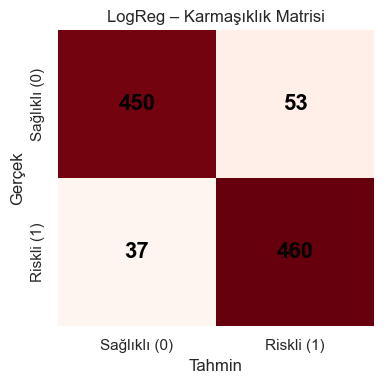


📌 LogReg – Classification Report
              precision    recall  f1-score   support

           0      0.924     0.895     0.909       503
           1      0.897     0.926     0.911       497

    accuracy                          0.910      1000
   macro avg      0.910     0.910     0.910      1000
weighted avg      0.910     0.910     0.910      1000



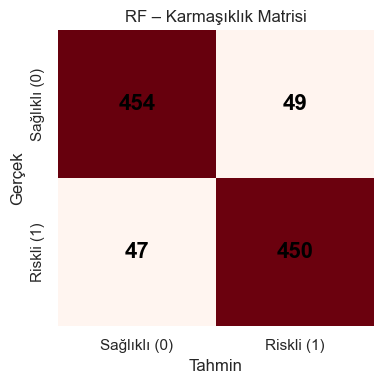


📌 RF – Classification Report
              precision    recall  f1-score   support

           0      0.906     0.903     0.904       503
           1      0.902     0.905     0.904       497

    accuracy                          0.904      1000
   macro avg      0.904     0.904     0.904      1000
weighted avg      0.904     0.904     0.904      1000



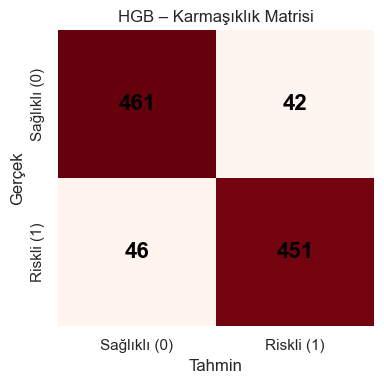


📌 HGB – Classification Report
              precision    recall  f1-score   support

           0      0.909     0.917     0.913       503
           1      0.915     0.907     0.911       497

    accuracy                          0.912      1000
   macro avg      0.912     0.912     0.912      1000
weighted avg      0.912     0.912     0.912      1000



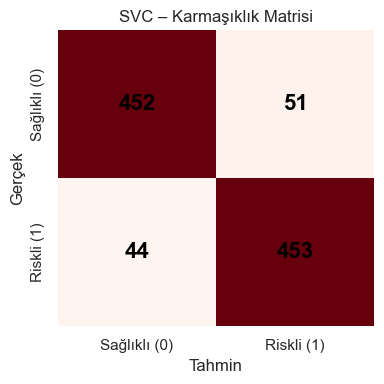


📌 SVC – Classification Report
              precision    recall  f1-score   support

           0      0.911     0.899     0.905       503
           1      0.899     0.911     0.905       497

    accuracy                          0.905      1000
   macro avg      0.905     0.905     0.905      1000
weighted avg      0.905     0.905     0.905      1000



In [82]:
for name, model in best_models.items():
    plot_cm_always_show(model, X_test, y_test, model_name=name)



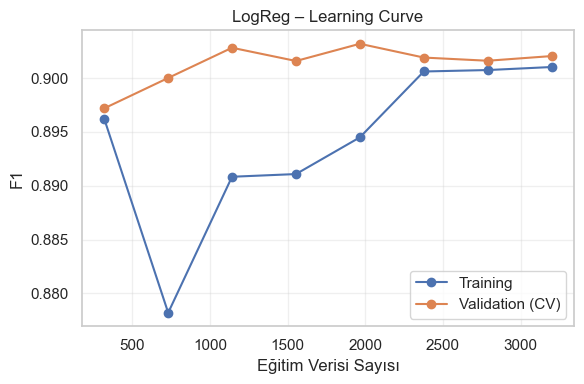

📌 LogReg – Learning Curve
Son noktada Train F1: 0.901
Son noktada Val   F1: 0.902
Fark (Train-Val): -0.001



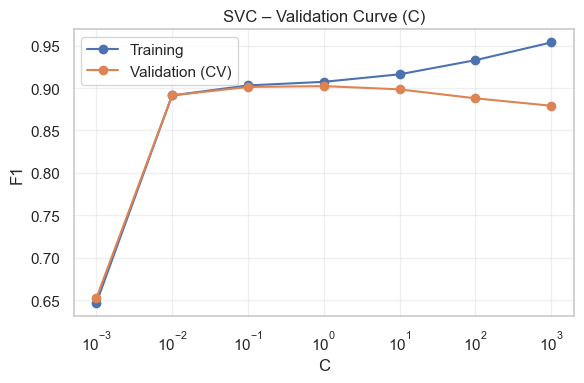

📌 SVC – Validation Curve (C)   [param_name: model__C]
En iyi C: 1
Train F1: 0.907
Val   F1: 0.902
Fark (Train-Val): 0.005



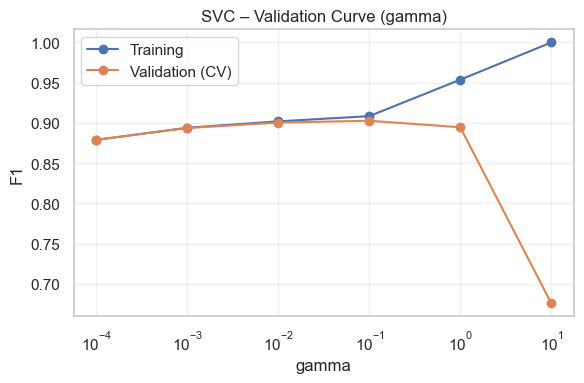

📌 SVC – Validation Curve (gamma)   [param_name: model__gamma]
En iyi gamma: 0.1
Train F1: 0.908
Val   F1: 0.903
Fark (Train-Val): 0.006



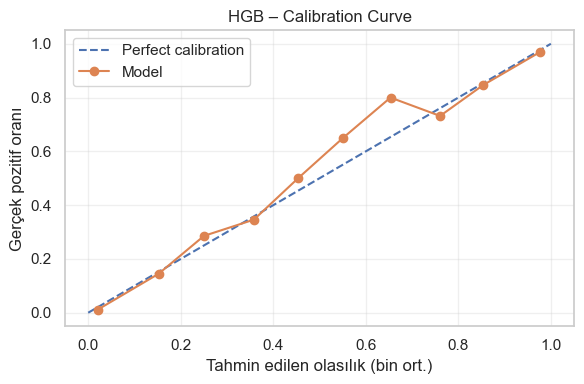

📌 HGB – Calibration Curve
Diyagonale yakınlık → olasılıkların genellemesi iyi (aşırı güven riski düşük).

📌 RF – OOB Overfitting Analizi (RF yeniden fit edildi: oob_score=True)
Training F1-score : 0.920
OOB Score         : 0.908
Fark (Train - OOB): 0.012



In [84]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import learning_curve, validation_curve, StratifiedKFold
from sklearn.calibration import calibration_curve
from sklearn.metrics import f1_score
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier


# -------------------------
# Yardımcı: Pipeline son estimator adımı ve prefix
# -------------------------
def _get_estimator_step_name(estimator):
    """
    Pipeline ise son adım adını döndürür (örn 'model'), değilse None.
    """
    if hasattr(estimator, "named_steps"):
        return list(estimator.named_steps.keys())[-1]
    return None

def _param_name_for(estimator, param):
    """
    Pipeline ise 'step__param' döndürür (örn 'model__C'),
    değilse 'param' döndürür.
    """
    step = _get_estimator_step_name(estimator)
    return f"{step}__{param}" if step else param


# =========================
# 1) LogReg: Learning Curve + skor farkı
# =========================
def logreg_learning_curve(model, X, y, scoring="f1", cv=5, title="LogReg – Learning Curve"):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=cv,
        scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(6,4))
    plt.plot(train_sizes, train_mean, "o-", label="Training")
    plt.plot(train_sizes, val_mean, "o-", label="Validation (CV)")
    plt.xlabel("Eğitim Verisi Sayısı")
    plt.ylabel(scoring.upper())
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"📌 {title}")
    print(f"Son noktada Train {scoring.upper()}: {train_mean[-1]:.3f}")
    print(f"Son noktada Val   {scoring.upper()}: {val_mean[-1]:.3f}")
    print(f"Fark (Train-Val): {train_mean[-1]-val_mean[-1]:.3f}\n")


# =========================
# 2) SVC: Validation Curve (C / gamma) - PIPELINE UYUMLU
# =========================
def svc_validation_curve(model, X, y, param="C", scoring="f1", cv=5, title_prefix="SVC – Validation Curve"):
    if param not in ["C", "gamma"]:
        raise ValueError("param sadece 'C' veya 'gamma' olabilir.")

    # Param aralığı
    if param == "C":
        param_range = np.logspace(-3, 3, 7)
    else:
        param_range = np.logspace(-4, 1, 6)

    # ✅ Pipeline ise model__C / model__gamma yap
    param_name = _param_name_for(model, param)

    train_scores, val_scores = validation_curve(
        model, X, y,
        param_name=param_name,
        param_range=param_range,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(6,4))
    plt.plot(param_range, train_mean, "o-", label="Training")
    plt.plot(param_range, val_mean, "o-", label="Validation (CV)")
    plt.xscale("log")
    plt.xlabel(param)
    plt.ylabel(scoring.upper())
    plt.title(f"{title_prefix} ({param})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    best_i = int(np.argmax(val_mean))
    print(f"📌 {title_prefix} ({param})   [param_name: {param_name}]")
    print(f"En iyi {param}: {param_range[best_i]:.6g}")
    print(f"Train {scoring.upper()}: {train_mean[best_i]:.3f}")
    print(f"Val   {scoring.upper()}: {val_mean[best_i]:.3f}")
    print(f"Fark (Train-Val): {train_mean[best_i]-val_mean[best_i]:.3f}\n")


# =========================
# 3) HGB: Calibration Curve
# =========================
def hgb_calibration_curve(model, X_test, y_test, n_bins=10, title="HGB – Calibration Curve"):
    if not hasattr(model, "predict_proba"):
        raise ValueError("Calibration Curve için predict_proba gerekli.")

    y_prob = model.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=n_bins, strategy="uniform")

    plt.figure(figsize=(6,4))
    plt.plot([0, 1], [0, 1], "--", label="Perfect calibration")
    plt.plot(mean_pred, frac_pos, "o-", label="Model")
    plt.xlabel("Tahmin edilen olasılık (bin ort.)")
    plt.ylabel("Gerçek pozitif oranı")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"📌 {title}")
    print("Diyagonale yakınlık → olasılıkların genellemesi iyi (aşırı güven riski düşük).\n")


# =========================
# 4) RF: OOB (Out-of-Bag) – gerçek overfitting testi
# =========================
def rf_oob_analysis(rf_model_or_pipeline, X_train, y_train, title="RF – OOB Overfitting Analizi"):
    # Pipeline ise RF estimator'ı bul
    rf_est = rf_model_or_pipeline
    if hasattr(rf_model_or_pipeline, "named_steps"):
        rf_est = list(rf_model_or_pipeline.named_steps.values())[-1]

    if not isinstance(rf_est, RandomForestClassifier):
        raise ValueError("Son adım RandomForestClassifier değil.")

    # Train F1 (pipeline üzerinden)
    y_train_pred = rf_model_or_pipeline.predict(X_train)
    train_f1 = f1_score(y_train, y_train_pred)

    # OOB hazır mı?
    if getattr(rf_est, "oob_score", False) and hasattr(rf_est, "oob_score_"):
        oob = float(rf_est.oob_score_)
        print(f"📌 {title}")
        print(f"Training F1-score : {train_f1:.3f}")
        print(f"OOB Score         : {oob:.3f}")
        print(f"Fark (Train - OOB): {train_f1 - oob:.3f}\n")
        return

    # Değilse: aynı parametrelerle klonla, oob_score=True yapıp yeniden fit et
    rf2 = clone(rf_est)
    rf2.set_params(oob_score=True, bootstrap=True)
    rf2.fit(X_train, y_train)

    oob = float(rf2.oob_score_)
    print(f"📌 {title} (RF yeniden fit edildi: oob_score=True)")
    print(f"Training F1-score : {train_f1:.3f}")
    print(f"OOB Score         : {oob:.3f}")
    print(f"Fark (Train - OOB): {train_f1 - oob:.3f}\n")


# =========================
# 5) Hepsini tek seferde çalıştır
# =========================
def run_overfitting_suite(best_models, X_train, y_train, X_test, y_test):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # LogReg
    logreg_learning_curve(best_models["LogReg"], X_train, y_train, scoring="f1", cv=cv,
                          title="LogReg – Learning Curve")

    # SVC: C
    svc_validation_curve(best_models["SVC"], X_train, y_train, param="C", scoring="f1", cv=cv,
                         title_prefix="SVC – Validation Curve")

    # SVC: gamma (sadece rbf ise)
    try:
        svc_obj = best_models["SVC"]
        svc_last = list(svc_obj.named_steps.values())[-1] if hasattr(svc_obj, "named_steps") else svc_obj
        kernel = getattr(svc_last, "kernel", None)
        if kernel == "rbf":
            svc_validation_curve(best_models["SVC"], X_train, y_train, param="gamma", scoring="f1", cv=cv,
                                 title_prefix="SVC – Validation Curve")
        else:
            print("ℹ️ SVC kernel 'rbf' değil → gamma eğrisi atlandı.\n")
    except Exception as e:
        print(f"ℹ️ SVC gamma eğrisi çizilemedi: {e}\n")

    # HGB calibration
    hgb_calibration_curve(best_models["HGB"], X_test, y_test, n_bins=10,
                          title="HGB – Calibration Curve")

    # RF OOB
    rf_oob_analysis(best_models["RF"], X_train, y_train, title="RF – OOB Overfitting Analizi")


# ÇALIŞTIR
run_overfitting_suite(best_models, X_train, y_train, X_test, y_test)


/opt/anaconda3/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:777: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:777: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights

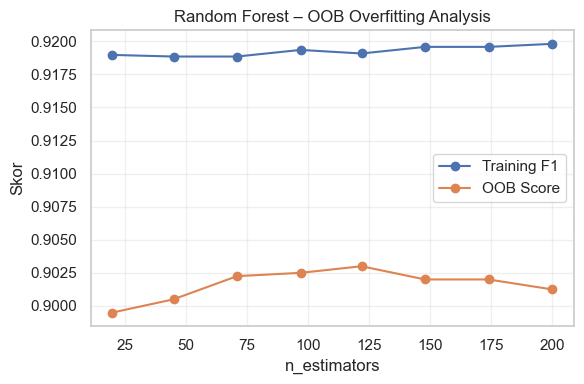

📌 RF – OOB Overfitting Sonucu
Final Train F1 : 0.920
Final OOB Score: 0.901
Gap            : 0.019
✅ Overfitting YOK (Train ≈ OOB)


In [89]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

def plot_rf_oob_overfitting(rf_pipeline, X_train, y_train):
    """
    Random Forest için OOB-based overfitting grafiği.
    Pipeline destekler.
    """

    # Pipeline ise son adımı al
    rf_est = rf_pipeline
    if hasattr(rf_pipeline, "named_steps"):
        rf_est = list(rf_pipeline.named_steps.values())[-1]

    if not isinstance(rf_est, RandomForestClassifier):
        raise ValueError("Model RandomForestClassifier değil.")

    # Preprocess varsa ayır
    if hasattr(rf_pipeline, "steps"):
        pre = rf_pipeline[:-1]
        Xtr = pre.fit_transform(X_train, y_train)
    else:
        Xtr = X_train

    # RF kopyası (orijinali bozmuyoruz)
    rf = clone(rf_est)
    rf.set_params(
        oob_score=True,
        bootstrap=True,
        warm_start=True
    )

    # n_estimators aralığı
    n_list = np.linspace(20, rf.n_estimators, 8).astype(int)
    n_list = np.unique(n_list)

    train_f1, oob_scores = [], []

    for n in n_list:
        rf.set_params(n_estimators=int(n))
        rf.fit(Xtr, y_train)

        y_train_pred = rf.predict(Xtr)
        train_f1.append(f1_score(y_train, y_train_pred))
        oob_scores.append(rf.oob_score_)

    # 📊 Grafik
    plt.figure(figsize=(6,4))
    plt.plot(n_list, train_f1, "o-", label="Training F1")
    plt.plot(n_list, oob_scores, "o-", label="OOB Score")
    plt.xlabel("n_estimators")
    plt.ylabel("Skor")
    plt.title("Random Forest – OOB Overfitting Analysis")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 📌 Sayısal yorum
    gap = train_f1[-1] - oob_scores[-1]
    print("📌 RF – OOB Overfitting Sonucu")
    print(f"Final Train F1 : {train_f1[-1]:.3f}")
    print(f"Final OOB Score: {oob_scores[-1]:.3f}")
    print(f"Gap            : {gap:.3f}")

    if gap < 0.05:
        print("✅ Overfitting YOK (Train ≈ OOB)")
    elif gap < 0.10:
        print("⚠️ Hafif overfitting")
    else:
        print("❌ Overfitting VAR")

plot_rf_oob_overfitting(best_models["RF"], X_train, y_train)        


In [54]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, classification_report, brier_score_loss
)
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.calibration import calibration_curve


# =========================================================
# Helpers
# =========================================================
def get_estimator_name(model):
    """Pipeline ise içindeki son estimator adını döndürür."""
    if hasattr(model, "named_steps") and "model" in model.named_steps:
        return model.named_steps["model"].__class__.__name__
    return model.__class__.__name__


def get_proba(model, X):
    """
    Binary ROC/Calibration için olasılık üretir.
    - predict_proba varsa onu kullanır
    - yoksa decision_function -> sigmoid approx
    """
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        return proba[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return 1 / (1 + np.exp(-scores))
    raise ValueError("Model predict_proba veya decision_function desteklemiyor.")


# =========================================================
# Plots
# =========================================================
def plot_confusion_matrices(y_true, y_pred, name="MODEL"):
    labels = np.unique(y_true)

    # Count
    cm_count = confusion_matrix(y_true, y_pred, labels=labels)
    ConfusionMatrixDisplay(cm_count, display_labels=labels).plot(values_format="d")
    plt.title(f"{name} – Confusion Matrix (Count)")
    plt.tight_layout()
    plt.show()

    # Normalized (row-wise)
    cm_norm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")
    ConfusionMatrixDisplay(cm_norm, display_labels=labels).plot(values_format=".2f")
    plt.title(f"{name} – Confusion Matrix (Normalized)")
    plt.tight_layout()
    plt.show()


def plot_calibration_curve_binary(model, X_test, y_test, name="MODEL", n_bins=10, strategy="quantile"):
    classes = np.unique(y_test)
    if len(classes) != 2:
        print(f"❗ {name}: Calibration curve sadece binary için. Sınıf sayısı={len(classes)}")
        return

    y_prob = get_proba(model, X_test)
    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=n_bins, strategy=strategy)

    auc = roc_auc_score(y_test, y_prob)
    brier = brier_score_loss(y_test, y_prob)

    plt.figure(figsize=(5,4))
    plt.plot([0,1], [0,1], "--", label="Perfect")
    plt.plot(mean_pred, frac_pos, marker="o", linewidth=2, label=f"{name} (Brier={brier:.4f}, AUC={auc:.3f})")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed positive rate")
    plt.title(f"{name} – Calibration Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"⚠️ Calibration: AUC={auc:.3f} | Brier={brier:.4f} (↓ daha iyi)")


def roc_overfit_report_binary(model, X_train, y_train, X_test, y_test, name="MODEL"):
    classes = np.unique(y_test)
    if len(classes) != 2:
        print(f"❗ {name}: ROC sadece binary için. Sınıf sayısı={len(classes)}")
        return

    # ROC
    y_prob = get_proba(model, X_test)
    auc = roc_auc_score(y_test, y_prob)

    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title(f"{name} – ROC Curve (AUC={auc:.3f})")
    plt.tight_layout()
    plt.show()

    # Overfit (Train vs Test)
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    f1_train = f1_score(y_train, y_pred_train, average="macro")
    f1_test  = f1_score(y_test,  y_pred_test,  average="macro")

    gap = f1_train - f1_test
    print("⚠️ Overfitting Analizi (F1-macro)")
    print(f"Train F1-macro: {f1_train:.4f}")
    print(f"Test  F1-macro: {f1_test:.4f}")
    print(f"Fark (Train-Test): {gap:.4f}")

    if gap > 0.05:
        print("📌 Yorum: Overfitting eğilimi VAR\n")
    else:
        print("📌 Yorum: Belirgin overfitting YOK\n")


# =========================================================
# Main evaluation (all-in-one)
# =========================================================
def evaluate_full_clean(model, X_train, y_train, X_test, y_test, name=None):
    if name is None:
        name = get_estimator_name(model)

    print("\n========================================")
    print(f"📌 MODEL: {name}")
    print("========================================")

    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    # Metrics
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test  = accuracy_score(y_test,  y_pred_test)

    f1_train = f1_score(y_train, y_pred_train, average="macro")
    f1_test  = f1_score(y_test,  y_pred_test,  average="macro")

    print(f"✅ Train Accuracy : {acc_train:.4f} | Test Accuracy : {acc_test:.4f}")
    print(f"✅ Train F1-macro : {f1_train:.4f} | Test F1-macro : {f1_test:.4f}")

    # Binary precision/recall
    classes = np.unique(y_test)
    if len(classes) == 2:
        prec = precision_score(y_test, y_pred_test, zero_division=0)
        rec  = recall_score(y_test, y_pred_test, zero_division=0)
        print(f"✅ Test Precision : {prec:.4f} | Test Recall : {rec:.4f}")

    print("\n📄 Classification Report (Test):")
    print(classification_report(y_test, y_pred_test))

    # Confusion matrices
    plot_confusion_matrices(y_test, y_pred_test, name=name)

    # ROC + Calibration (binary)
    if len(classes) == 2:
        roc_overfit_report_binary(model, X_train, y_train, X_test, y_test, name=name)
        plot_calibration_curve_binary(model, X_test, y_test, name=name)

    # Learning curve
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        cv=cv,
        scoring="f1_macro",
        train_sizes=np.linspace(0.1, 1.0, 6),
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)

    plt.figure(figsize=(6,4))
    plt.plot(train_sizes, train_mean, marker="o", label="Train F1-macro")
    plt.plot(train_sizes, val_mean, marker="o", label="CV F1-macro")
    plt.title(f"{name} – Learning Curve (F1-macro)")
    plt.xlabel("Training samples")
    plt.ylabel("F1-macro")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("========================================\n")




📌 MODEL: HGB (HistGradientBoostingClassifier)
✅ Train Accuracy : 0.9163 | Test Accuracy : 0.9120
✅ Train F1-macro : 0.9162 | Test F1-macro : 0.9120
✅ Test Precision : 0.9148 | Test Recall : 0.9074

📄 Classification Report (Test):
              precision    recall  f1-score   support

           0       0.91      0.92      0.91       503
           1       0.91      0.91      0.91       497

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000



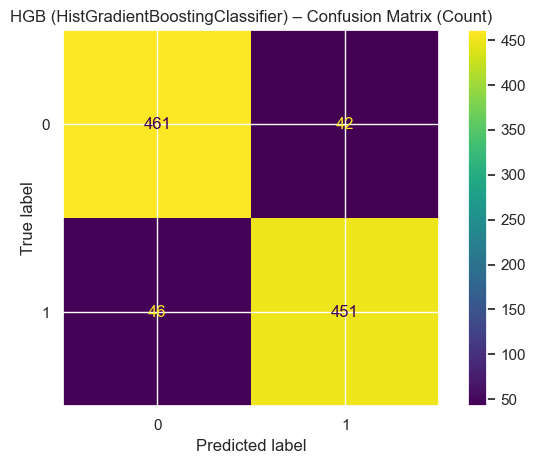

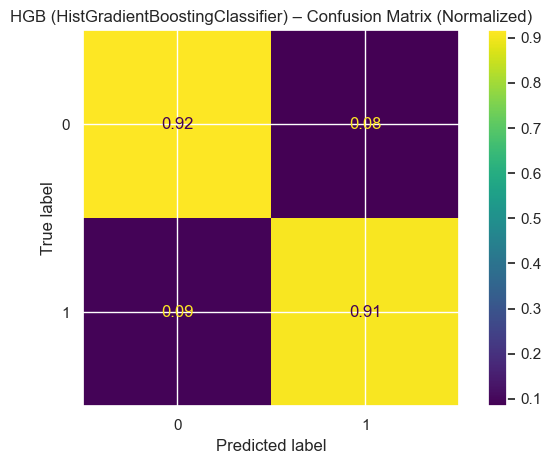

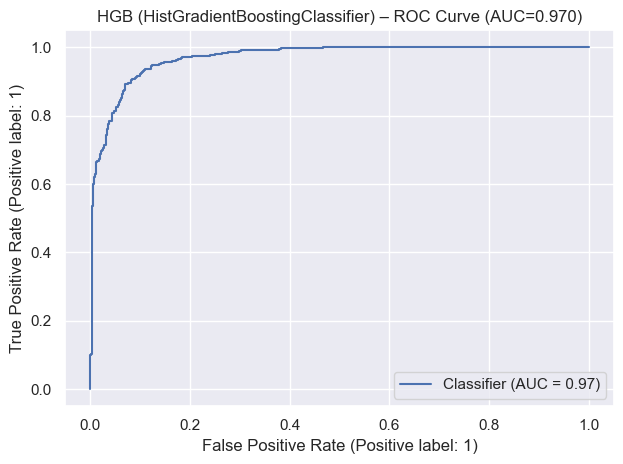

⚠️ Overfitting Analizi (F1-macro)
Train F1-macro: 0.9162
Test  F1-macro: 0.9120
Fark (Train-Test): 0.0043
📌 Yorum: Belirgin overfitting YOK



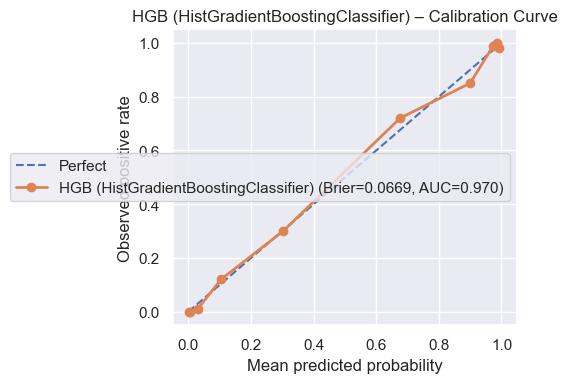

⚠️ Calibration: AUC=0.970 | Brier=0.0669 (↓ daha iyi)


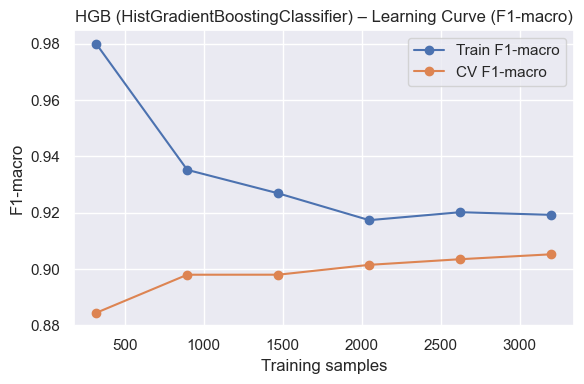

In [55]:

# =========================================================
# RUN for best HGB
# =========================================================
best_model = best_models["HGB"]          # senin sözlüğünden geliyor
best_name  = "HGB (HistGradientBoostingClassifier)"

evaluate_full_clean(best_model, X_train, y_train, X_test, y_test, name=best_name)


In [56]:
import joblib
from datetime import datetime
from pathlib import Path

# -------------------------------------------------
# BEST MODEL
# -------------------------------------------------
best_model = best_models["HGB"]

# -------------------------------------------------
# KLASÖR (yoksa oluştur)
# -------------------------------------------------
models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------
# DOSYA ADI (tez / sunum uyumlu)
# -------------------------------------------------
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
model_filename = f"best_model_HGB_pipeline_{timestamp}.joblib"
model_path = models_dir / model_filename

# -------------------------------------------------
# KAYDET
# -------------------------------------------------
joblib.dump(best_model, model_path)

print(f"✅ BEST MODEL (HGB) başarıyla kaydedildi → {model_path}")


✅ BEST MODEL (HGB) başarıyla kaydedildi → models/best_model_HGB_pipeline_20251218_2004.joblib


In [90]:
import joblib
from pathlib import Path

# Model
model_to_save = best_models["HGB"]

# Proje kökü = notebook'un çalıştığı yer
BASE_DIR = Path.cwd()

# models klasörü
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

# Dosya yolu
MODEL_PATH = MODEL_DIR / "hgb_pipeline.joblib"

# Kaydet
joblib.dump(model_to_save, MODEL_PATH)

print("✅ Model kaydedildi")
print("📄 Yol:", MODEL_PATH.resolve())


✅ Model kaydedildi
📄 Yol: /Users/betulbostan/Desktop/teknoloji_ruh_sagligi/models/hgb_pipeline.joblib


In [91]:
import sklearn, sys
print("python:", sys.version)
print("sklearn:", sklearn.__version__)


python: 3.11.7 (main, Dec 15 2023, 12:09:04) [Clang 14.0.6 ]
sklearn: 1.2.2
